# Main Quest 01
## 1. 모델 구조 변경 

기존 트랜스포머

- 인코더 :  질문을 읽고 내용을 파악
- 디코더 : 인코더에  내용을 전달받아 답변을 작성

GPT-1

- 디코더만 사용
- 인코더를 완전히 없앰
- 앞에 나온 내용을 보면서 다음 내용을 스스로 이어서 씀

이 변경으로 인해 코드에서 아래 클래스가 제거되거나 이름 변경

- EncoderLayer, Encoder 클래스 → 완전히 제거
- DecoderLayer → GPTBlock 으로 이름 변경 (내부 구조도 변경)
- Transformer → GPT1Model 로 이름 변경 (디코더만 남김)

---
## 2. 데이터 구성 방식 변경 : QA를 하나로 합침

기존 트랜스포머는 질문과 답변을 따로 나누어서 모델에 입력

- 인코더 입력 → 오늘 날씨가 좋다
- 디코더 입력 → 정말요?
- 마치 시험지와 답안지가 별도로 존재하는 것과 같은 모양

GPT-1은 질문과 답변을 한 장에 이어 붙여서 입력

- 하나의 입력 → [시작] 오늘 날씨가 좋다 [구분] 정말요? [끝]
- 앞 내용을 보고 뒷 내용을 이어서 채우는 방식
- 모델의 학습 목표가 "답변 맞추기"에서 "다음 단어 맞추기"로 바뀜

이 변경으로 인해 코드에서 아래 클래스 이름 변경

- KoreanChatbotDataset → GPTPretrainDataset 으로 이름 변경

---

## 3. 위치 정보 추가 방식 변경 : 공식으로 계산하던 것을 직접 외우도록 변경

트랜스포머는 단어의 순서 정보를 수학 공식(sin, cos)으로 계산, 입력

- 공식에 따라 항상 같은 값 나옴
- 학습을 해도 값이 변하지 않음

GPT-1은 위치 정보를 직접 학습

- 1번째 자리, 2번째 자리, 3번째 자리에 어떤 값이 어울리는지 스스로 학습함
- GPT-1 논문에서 "learned position embeddings" 라고 표현한 방식

이 변경으로 인해 코드에서 아래 클래스 이름 변경

- PositionalEncoding → GPTPositionalEmbedding 으로 이름 변경

---

## 4. 마스크 변경 : 두 종류 마스크를 한 종류로 줄임


기존 트랜스포머는 두 종류의 마스크를 사용

- 패딩 마스크 : 빈칸(패딩)으로 채워진 자리를 가림
- Look-Ahead 마스크 : 아직 나오지 않은 미래 단어를 가림

GPT-1은 Look-Ahead 마스크 한 종류만 사용

- 인코더가 없어졌으므로 인코더용 패딩 마스크가 필요 없어짐
- 미래 단어만 가리면 충분

이 변경으로 인해 코드에서 패딩 마스크 함수 제거

- create_padding_mask 함수 → 제거
- create_look_ahead_mask 함수 → 유지 (GPT-1에서도 필요)

---

## 5. 학습 목표 변경 : 선생님이 가르치던 것을 혼자 책 읽으며 배우도록 변경

기존 트랜스포머의 학습 방식은 선생님이 정답을 알려주는 방식

- 질문을 보여주고 정답 답변을 가르쳐주며 따라 하도록 훈련
- Teacher Forcing 이라고 부르는 방식

GPT-1의 학습 방식은 혼자 책을 읽으며 다음 내용을 예측하는 방식

- 앞에 나온 단어들을 보고 다음 단어가 무엇일지 스스로 예측
- 틀리면 수정하면서 점점 더 잘 예측하게 됨
- 이것이 GPT-1 논문의 핵심인 사전학습(Pretrain) 방식
- 이번 Main Quest에서는 사전학습 단계만 구현

이 변경으로 인해 코드에서 아래 내용이 변경

- train_step 함수 : 3개 입력(질문, 답변입력, 답변정답) → 2개 입력(전체문장, 다음단어정답)
- 모델 호출 : model(enc_input, dec_input) → model(input_ids)

---

## 6. GPTBlock 내부 변경 : 디코더 안에 있던 교차 참조 기능 제거

기존 DecoderLayer(디코더 레이어)는 세 단계로 구성

- 1단계 : 자기 자신의 내용을 스스로 살펴보기 (셀프 어텐션)
- 2단계 : 인코더가 파악한 내용을 참고하기 (크로스 어텐션)
- 3단계 : 최종 답변 내용 생성하기 (피드포워드)

GPTBlock은 두 단계만 남김

- 1단계 : 자기 자신의 내용을 스스로 살펴보기 (Masked 셀프 어텐션) → 유지
- 2단계 : 인코더 참고하기 → 인코더가 없으므로 제거
- 2단계 : 최종 내용 생성하기 (피드포워드) → 유지 (순서가 3→2로 바뀜)

이 변경으로 인해 코드에서 아래 내용이 제거

- encdec_mha (크로스 어텐션) 제거
- forward 함수의 enc_outputs, padding_mask 파라미터 제거

### 1. 환경구성

In [1]:
!pip install sentencepiece -q

In [2]:
# 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm
import math
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
 
print("torch 버전:", torch.__version__)
print("sentencepiece 버전:", spm.__version__)

torch 버전: 2.7.1+cu118
sentencepiece 버전: 0.2.1


In [3]:
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

--2026-04-21 05:22:47--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-04-21 05:22:47--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv.16’

ChatbotData.csv.16  100%[===================>] 868.99K  5.19MB/s    in 0.2s    

2026-04-21 05:22:48 (5.19 MB/s) - ‘ChatbotData.csv.16’ saved [889842/889842]



### 2. 데이터 수집

In [4]:
DATA_PATH = "ChatbotData.csv"
 
df = pd.read_csv(DATA_PATH)
print("전체 샘플 수:", len(df))
print(df.head(5))
 
pairs = list(zip(df["Q"], df["A"]))
print("\n첫 번째 쌍:", pairs[0])

전체 샘플 수: 11823
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0

첫 번째 쌍: ('12시 땡!', '하루가 또 가네요.')


### 3. 데이터 전처리 함수 정의

In [5]:
def preprocess_sentence(sentence):
    """
    한국어 전처리 함수
 
    영어와 다른 점:
      - 소문자 변환 불필요 (한국어는 대소문자 없음)
      - 한글(가-힣) + 영문 + 숫자 + 기본 구두점만 유지
      - 나머지 특수문자·이모지 등은 공백으로 제거
 
    처리 순서:
      1) 양쪽 공백 제거
      2) 구두점 앞뒤에 공백 삽입 (토크나이저 분리 보조)
      3) 연속 공백 → 단일 공백
      4) 한글·영문·숫자·구두점 외 제거
      5) 최종 공백 제거
    """
    sentence = str(sentence).strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence) # 구두점 앞뒤 공백
    sentence = re.sub(r"[ ]+", " ", sentence)         # 연속 공백 제거
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence) # 특수문자 제거
    sentence = sentence.strip()
    return sentence
 
 
cleaned_pairs = []
for q, a in pairs:
    q_clean = preprocess_sentence(q)
    a_clean = preprocess_sentence(a)
    if q_clean and a_clean:
        cleaned_pairs.append((q_clean, a_clean))
 
print("전처리 후 샘플 수:", len(cleaned_pairs))


전처리 후 샘플 수: 11823


### 4.데이터 전처리 분석

In [6]:
samples = [
    "오늘 기분이 너무 안 좋아😢",
    "취업준비중인데 너무힘들어요!!",
    "1지망 학교 떨어졌어ㅠㅠ",
]
print("=== 전처리 전후 비교 ===")
for s in samples:
    print(f"  원본    : {s}")
    print(f"  전처리후: {preprocess_sentence(s)}")
    print()

=== 전처리 전후 비교 ===
  원본    : 오늘 기분이 너무 안 좋아😢
  전처리후: 오늘 기분이 너무 안 좋아

  원본    : 취업준비중인데 너무힘들어요!!
  전처리후: 취업준비중인데 너무힘들어요 ! !

  원본    : 1지망 학교 떨어졌어ㅠㅠ
  전처리후: 1지망 학교 떨어졌어



### 5. SentencePiece 토크나이저 학습

In [7]:
CORPUS_FILE = "ko_corpus.txt"
SPM_PREFIX  = "spm_korean"
VOCAB_SIZE  = 8000
 
with open(CORPUS_FILE, "w", encoding="utf-8") as f:
    for q, a in cleaned_pairs:
        f.write(q + "\n")
        f.write(a + "\n")
 
spm.SentencePieceTrainer.Train(
    input=CORPUS_FILE,
    model_prefix=SPM_PREFIX,
    vocab_size=VOCAB_SIZE,
    character_coverage=1.0,   # 한국어 전체 문자 커버
    model_type="bpe",         # 서브워드 토크나이징
    max_sentence_length=999999,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,
)
print("SentencePiece 학습 완료!")

SentencePiece 학습 완료!


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ko_corpus.txt
  input_format: 
  model_prefix: spm_korean
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differenti

### 6. 토크나이저 로드 및 분석

In [8]:
sp = spm.SentencePieceProcessor()
sp.Load(f"{SPM_PREFIX}.model")
print("어휘 사전 크기:", sp.GetPieceSize())
 
print("\n=== 토크나이징 결과 분석 ===")
test_sents = [
    "오늘 날씨가 너무 좋아",
    "취업 준비가 너무 힘들어",
    "사랑하는 사람이 생겼어",
]
for s in test_sents:
    tokens  = sp.encode(s, out_type=str)
    ids     = sp.encode(s, out_type=int)
    decoded = sp.decode(ids)
    print(f"  문장    : {s}")
    print(f"  서브워드: {tokens}")
    print(f"  토큰 수 : {len(tokens)}")
    print(f"  디코딩  : {decoded}")
    print()

어휘 사전 크기: 8000

=== 토크나이징 결과 분석 ===
  문장    : 오늘 날씨가 너무 좋아
  서브워드: ['▁오늘', '▁날씨가', '▁너무', '▁좋아']
  토큰 수 : 4
  디코딩  : 오늘 날씨가 너무 좋아

  문장    : 취업 준비가 너무 힘들어
  서브워드: ['▁취업', '▁준비가', '▁너무', '▁힘들어']
  토큰 수 : 4
  디코딩  : 취업 준비가 너무 힘들어

  문장    : 사랑하는 사람이 생겼어
  서브워드: ['▁사랑하는', '▁사람이', '▁생겼어']
  토큰 수 : 3
  디코딩  : 사랑하는 사람이 생겼어



## 2. GPT-1 사전학습 데이터셋 구성
### 7. 기존 병렬 데이터셋(enc_input/dec_input/target)을 GPT-1 방식의 단일 연속 시퀀스로 변경
     - 기존: (질문, 답변) 쌍을 분리해서 인코더/디코더에 각각 입력
     - GPT-1: [BOS] 질문 [SEP] 답변 [EOS] 형태의 단일 시퀀스로 구성
     - 학습 목표: 다음 토큰 예측 (언어 모델링)

In [11]:
# GPT-1 사전학습 데이터셋
"""
기존 KoreanChatbotDataset:
 - enc_input: [BOS] 질문 [EOS] + 패딩  (인코더 입력)
 - dec_input: [BOS] 답변               (디코더 입력)
 - target   :       답변 [EOS]         (디코더 타겟)
 → Encoder-Decoder 구조에 맞는 병렬 데이터

 GPT-1 GPTPretrainDataset (변경):
 - input_ids : [BOS] 질문 [SEP] 답변 [EOS] + 패딩  (단일 시퀀스)
 - target_ids: 질문 [SEP] 답변 [EOS] + 패딩        (input을 1칸 뒤로 이동)
 → Decoder-Only 구조에 맞는 단일 시퀀스 데이터
 → GPT-1 논문의 언어 모델링 목표: P(u_i | u_{i-k}, ..., u_{i-1})
"""

MAX_LENGTH = 40  # 기존과 동일한 최대 길이 유지
MAX_LENGTH = 40  # 기존과 동일한 최대 길이 유지

# 클래스명 변경: KoreanChatbotDataset → GPTPretrainDataset
class GPTPretrainDataset(Dataset):
    """
    GPT-1 사전학습용 데이터셋

    [변경사항]
    기존 트랜스포머: (enc_input, dec_input, target) 3개 텐서 반환
    GPT-1          : (input_ids, target_ids) 2개 텐서 반환

    [데이터 구성 방식]
    기존: [BOS] Q [EOS] → [BOS] A [EOS]  (질문-답변 분리)
    GPT : [BOS] Q [SEP] A [EOS]           (하나의 연속 시퀀스)

    [학습 목표]
    GPT-1 논문 수식 L1(U) = sum log P(u_i | u_{i-k},...,u_{i-1}; Theta)
    → 각 위치에서 다음 토큰을 예측하는 언어 모델링
    """
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.data = []

        bos_id = sp.bos_id()   # 1  : 문장 시작
        eos_id = sp.eos_id()   # 2  : 문장 종료
        pad_id = 0             # 0  : 패딩
        # SEP 토큰 추가 (변경사항): 질문과 답변을 구분하는 구분자
        # GPT-1 논문에서 fine-tuning 시 delimiter token($) 사용
        # Pretrain에서는 EOS 토큰을 SEP으로 재활용
        sep_id = eos_id        # EOS를 SEP으로 활용 (단순화)

        for q_text, a_text in pairs:
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 기존과 변경된 사항: q_tokens, a_tokens 분리 구성
            # GPT-1: [BOS] + 질문 + [SEP] + 답변 + [EOS] 단일 시퀀스
            # GPT-1 논문: "we convert all structured inputs into token sequences"
            sequence = [bos_id] + q_ids + [sep_id] + a_ids + [eos_id]

            # 최대 길이 초과 시 제외 (기존과 동일)
            if len(sequence) > max_length:
                continue

            # 패딩 추가 (기존과 동일)
            sequence += [pad_id] * (max_length - len(sequence))

            # 기존과 변경된 사항 : dec_input = a_tokens[:-1], target = a_tokens[1:]
            # GPT-1: input_ids = sequence[:-1], target_ids = sequence[1:]
            # → 전체 시퀀스에서 1칸씩 이동하며 다음 토큰 예측
            input_ids  = sequence[:-1]   # 입력: 마지막 토큰 제외
            target_ids = sequence[1:]    # 타겟: 첫 번째 토큰 제외 (1칸 이동)

            self.data.append({
                "input_ids" : input_ids,
                "target_ids": target_ids,
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        s = self.data[idx]
        return (
            torch.tensor(s["input_ids"],  dtype=torch.long),
            torch.tensor(s["target_ids"], dtype=torch.long),
        )

# 클래스명 변경: KoreanChatbotDataset → GPTPretrainDataset
dataset    = GPTPretrainDataset(cleaned_pairs, sp, max_length=MAX_LENGTH)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"GPT-1 사전학습 데이터셋 구성 완료!")
print(f"유효 샘플 수: {len(dataset):,} 개")

# 입력 형태 검증 
for input_ids, target_ids in dataloader:
    print(f"\n=== 모델 입력 형태 확인 ===")
    print(f"input_ids  shape: {input_ids.shape}")   # (batch, seq_len-1)
    print(f"target_ids shape: {target_ids.shape}")  # (batch, seq_len-1)
    print(f"\n[샘플 확인]")
    print(f"input_ids  [0]: {input_ids[0].tolist()}")
    print(f"target_ids [0]: {target_ids[0].tolist()}")
    print(f"\n[디코딩 확인]")
    print(f"입력 시퀀스: {sp.decode(input_ids[0].tolist())}")
    print(f"타겟 시퀀스: {sp.decode(target_ids[0].tolist())}")
    break

GPT-1 사전학습 데이터셋 구성 완료!
유효 샘플 수: 11,821 개

=== 모델 입력 형태 확인 ===
input_ids  shape: torch.Size([64, 39])
target_ids shape: torch.Size([64, 39])

[샘플 확인]
input_ids  [0]: [1, 1613, 6808, 3669, 902, 2, 875, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
target_ids [0]: [1613, 6808, 3669, 902, 2, 875, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[디코딩 확인]
입력 시퀀스: 무서워서 뛰어 왔어 조심하세요 .
타겟 시퀀스: 무서워서 뛰어 왔어 조심하세요 .


### 8. 병렬 데이터 구축 통계 분석

In [12]:
# GPT-1 데이터셋 통계 분석
# 기존: enc_input/dec_input/target 3개 구조
# GPT-1: input_ids/target_ids 2개 구조 (단일 시퀀스)

q_lens = [len(sp.encode(q)) for q, a in cleaned_pairs]
a_lens = [len(sp.encode(a)) for q, a in cleaned_pairs]

print("=== GPT-1 사전학습 데이터 통계 ===")
print(f"  원본 쌍              : {len(pairs):,} 개")
print(f"  전처리 후            : {len(cleaned_pairs):,} 개")
print(f"  유효 샘플 수         : {len(dataset):,} 개  (max_length={MAX_LENGTH} 초과 제외)")
print(f"  필터링 유지율        : {len(dataset)/len(pairs)*100:.1f}%")
print(f"  질문 평균 토큰 수    : {sum(q_lens)/len(q_lens):.1f}")
print(f"  답변 평균 토큰 수    : {sum(a_lens)/len(a_lens):.1f}")
print(f"  [BOS]+Q+[SEP]+A+[EOS] 평균 길이: {sum(q_lens[i]+a_lens[i]+3 for i in range(len(q_lens)))/len(q_lens):.1f}")
print()

# 기존 3개 텐서 → GPT-1 2개 텐서 확인
for input_ids, target_ids in dataloader:
    print(f"[변경] 기존 (enc_input, dec_input, target) 3개 텐서")
    print(f"[변경] GPT-1 (input_ids, target_ids) 2개 텐서")
    print(f"  input_ids  shape : {input_ids.shape}")
    print(f"  target_ids shape : {target_ids.shape}")
    break

=== GPT-1 사전학습 데이터 통계 ===
  원본 쌍              : 11,823 개
  전처리 후            : 11,823 개
  유효 샘플 수         : 11,821 개  (max_length=40 초과 제외)
  필터링 유지율        : 100.0%
  질문 평균 토큰 수    : 5.4
  답변 평균 토큰 수    : 5.8
  [BOS]+Q+[SEP]+A+[EOS] 평균 길이: 14.2

[변경] 기존 (enc_input, dec_input, target) 3개 텐서
[변경] GPT-1 (input_ids, target_ids) 2개 텐서
  input_ids  shape : torch.Size([64, 39])
  target_ids shape : torch.Size([64, 39])


### 9. GPT-1 모델 클래스 정의
기존 트랜스포머 클래스를 GPT-1 논문 기반으로 수정
**주요 변경사항:**
1. `PositionalEncoding` (sin/cos) → `GPTPositionalEmbedding` (학습 가능)
2. `EncoderLayer`, `Encoder` 클래스 **제거**
3. `DecoderLayer` → `GPTBlock` (Cross-Attention 제거)
4. `Decoder` → `GPTDecoder` (단일 시퀀스 입력)
5. `Transformer` → `GPT1Model` (Decoder-Only 구조)

> GPT-1 논문: "We trained a 12-layer decoder-only transformer with masked self-attention heads"

In [13]:
# GPT-1 모델 클래스 정의

# Positional Encoding → GPT Positional Embedding
# GPT-1 GPTPositionalEmbedding 변경:
#   - nn.Embedding으로 위치 임베딩 학습
#   - GPT-1 논문: "We used learned position embeddings
#     instead of the sinusoidal version"
#   - 토큰 임베딩과 위치 임베딩을 합산하여 입력 구성

# 클래스명 변경: PositionalEncoding → GPTPositionalEmbedding
class GPTPositionalEmbedding(nn.Module):
    """
    학습 가능한 위치 임베딩

    기존 PositionalEncoding과 차이:
    - 기존: sin/cos 공식 기반 고정값 → self.pos_encoding = self._build(...)
    - GPT-1: nn.Embedding으로 학습 → self.pos_embedding = nn.Embedding(...)

    GPT-1 논문 인용:
    "We used learned position embeddings instead of the sinusoidal version"
    """
    def __init__(self, max_length, d_model):
        super().__init__()
        # [변경] sin/cos 계산 제거 → 학습 가능한 nn.Embedding 사용
        # 기존: self.pos_encoding = self._build(position, d_model)
        self.pos_embedding = nn.Embedding(max_length, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        # 위치 인덱스 생성 후 임베딩 조회(변경사항)
        # 기존: return x + self.pos_encoding[:, :x.size(1), :].to(x.device)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        return x + self.pos_embedding(positions)  # 토큰 임베딩 + 위치 임베딩

# Scaled Dot-Product Attention(GPT-1도 동일한 scaled dot-product attention 사용)
def scaled_dot_product_attention(query, key, value, mask=None):
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))
    logits    = matmul_qk / math.sqrt(key.size(-1))
    if mask is not None:
        logits = logits + (mask * -1e9)
    weights = F.softmax(logits, dim=-1)
    return torch.matmul(weights, value), weights

# Multi-Head Attention (기존과 동일)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads   = num_heads
        self.d_model     = d_model
        self.depth       = d_model // num_heads
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense   = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.out_dense   = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, query, key, value, mask=None):
        b = query.size(0)
        q = self.split_heads(self.query_dense(query), b)
        k = self.split_heads(self.key_dense(key),     b)
        v = self.split_heads(self.value_dense(value), b)
        attn, _ = scaled_dot_product_attention(q, k, v, mask)
        attn = attn.permute(0, 2, 1, 3).contiguous().view(b, -1, self.d_model)
        return self.out_dense(attn)

#  Mask 함수
# GPT-1 (변경): Look-Ahead Mask만 사용
#   - Encoder가 없으므로 Encoder padding mask 불필요
#   - Cross-Attention이 없으므로 dec_padding_mask 불필요
#   - 단방향(Masked) Self-Attention을 위한 Look-Ahead Mask만 사용
# create_padding_mask 제거 (Encoder 제거로 불필요)
# def create_padding_mask(x): ← 이 함수는 GPT-1에서 제거

# Look-Ahead Mask만 사용 (GPT-1 Masked Self-Attention용)
def create_look_ahead_mask(x):
    """
    GPT-1 Masked Self-Attention용 Look-Ahead Mask

    기존: Padding Mask와 Look-Ahead Mask를 결합
    GPT-1: Look-Ahead Mask만 사용 (미래 토큰만 차단)

    GPT-1 논문: "masked self-attention heads"
    → 현재 위치 이전 토큰들만 참조 가능 (Causal / Auto-Regressive)
    """
    seq_len    = x.size(1)
    # 상삼각 행렬: 미래 위치를 1로 마스킹
    look_ahead = (1 - torch.tril(torch.ones(seq_len, seq_len))).unsqueeze(0).unsqueeze(1).to(x.device)
    # [변경] 기존: padding mask와 결합 → GPT-1: look_ahead만 반환
    # 기존: padding = create_padding_mask(x); return torch.max(look_ahead, padding)
    return look_ahead  # Look-Ahead Mask만 반환

# EncoderLayer → 제거 (GPT-1에는 Encoder 없음)
# 기존 EncoderLayer 클래스 제거:
# class EncoderLayer(nn.Module): ← GPT-1에서 제거
# 기존 Encoder 클래스 제거:
# class Encoder(nn.Module):  ← GPT-1에서 제거


# DecoderLayer → GPTBlock
# GPT-1 GPTBlock (변경):
#   1) Masked Self-Attention (self_mha)→ 유지 (Look-Ahead Mask 적용)
#   2) Cross-Attention 제거            → GPT-1은 단일 시퀀스만 처리
#   3) FFN                             → 유지


# 클래스명 변경: DecoderLayer → GPTBlock
class GPTBlock(nn.Module):
    """
    GPT-1 트랜스포머 블럭

    기존 DecoderLayer와의 차이:
    - 제거: encdec_mha (Cross-Attention) - Encoder가 없으므로 불필요
    - 제거: norm2, dropout2 (Cross-Attention 관련)
    - 유지: self_mha (Masked Self-Attention)
    - 유지: ffn (Feed-Forward Network)

    GPT-1 논문: "a multi-headed self-attention operation over the input
    context tokens followed by position-wise feedforward layers"
    """
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()

        # Masked Self-Attention
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1    = nn.LayerNorm(d_model, eps=1e-6)

        # Cross-Attention - Encoder 제거로 불필요
        # self.encdec_mha = MultiHeadAttention(d_model, num_heads)  ← 제거
        # self.norm2 = nn.LayerNorm(d_model, eps=1e-6)              ← 제거

        # FFN 
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.ReLU(), nn.Linear(ff_dim, d_model)
        )
        self.norm2    = nn.LayerNorm(d_model, eps=1e-6)  # FFN 후 LayerNorm

        self.dropout1 = nn.Dropout(dropout)
        # [제거] dropout2 (Cross-Attention 관련) ← 제거
        self.dropout2 = nn.Dropout(dropout)   # FFN 드롭아웃으로 재사용

    # forward 파라미터 변경
    # GPT-1: forward(self, x, mask) - enc_outputs, padding_mask 제거
    def forward(self, x, mask=None):
        """
        기존 DecoderLayer.forward와 차이:
        - 제거: enc_outputs 파라미터 (Encoder 출력 불필요)
        - 제거: padding_mask 파라미터 (Cross-Attention 불필요)
        - 제거: Cross-Attention 연산 (2번째 서브레이어)
        """
        # Masked Self-Attention + 잔차 연결 + LayerNorm
        out1 = self.norm1(x + self.dropout1(self.self_mha(x, x, x, mask)))

        # Cross-Attention (기존 encdec_mha) ← GPT-1에서 제거
        # out2 = self.norm2(out1 + self.dropout2(self.encdec_mha(out1, enc_outputs, enc_outputs, padding_mask)))

        # FFN + 잔차 연결 + LayerNorm (순서 변경: 3→2)
        out2 = self.norm2(out1 + self.dropout2(self.ffn(out1)))
        return out2

# Decoder → GPTDecoder
# GPT-1 GPTDecoder (변경):
#   - 입력: (x, mask) - enc_outputs 제거
#   - 단일 시퀀스만 처리 (Decoder-Only)
#   - PositionalEncoding → GPTPositionalEmbedding 사용


# 클래스명 변경: Decoder → GPTDecoder
class GPTDecoder(nn.Module):
    """
    GPT-1 디코더 스택

    기존 Decoder와의 차이:
    - 변경: PositionalEncoding → GPTPositionalEmbedding (학습 가능)
    - 변경: DecoderLayer → GPTBlock (Cross-Attention 제거)
    - 제거: enc_outputs 파라미터 (Encoder 출력 불필요)
    - 제거: padding_mask 파라미터
    """
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads,
                 max_length=40, dropout=0.1):
        super().__init__()
        self.d_model   = d_model

        # 토큰 임베딩
        self.embedding = nn.Embedding(vocab_size, d_model)

        # PositionalEncoding → GPTPositionalEmbedding
        # 기존: self.pos_encoding = PositionalEncoding(vocab_size, d_model)
        self.pos_embedding = GPTPositionalEmbedding(max_length, d_model)

        self.dropout = nn.Dropout(dropout)

        # DecoderLayer → GPTBlock
        # 기존: self.dec_layers = nn.ModuleList([DecoderLayer(...)])
        self.gpt_blocks = nn.ModuleList([
            GPTBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    # forward 파라미터 변경
    # 기존: forward(self, x, enc_outputs, look_ahead_mask, padding_mask)
    # GPT-1: forward(self, x, mask)
    def forward(self, x, mask=None):
        # 토큰 임베딩 + 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # PositionalEncoding → GPTPositionalEmbedding
        # 기존: x = self.dropout(self.pos_encoding(x))
        x = self.dropout(self.pos_embedding(x))

        # DecoderLayer → GPTBlock, 파라미터 변경
        # 기존: for layer in self.dec_layers: x = layer(x, enc_outputs, look_ahead_mask, padding_mask)
        for block in self.gpt_blocks:
            x = block(x, mask)
        return x

# Transformer → GPT1Model (Decoder-Only)
# GPT-1 GPT1Model (변경):
#   - self.decoder = GPTDecoder(...)  → Decoder-Only
#   - Look-Ahead Mask만 사용
#   - 입력: (input_ids,) 단일 텐서

# 클래스명 변경: Transformer → GPT1Model
class GPT1Model(nn.Module):
    """
    GPT-1 언어 모델 (Decoder-Only)

    기존 Transformer와의 차이:
    - 제거: self.encoder (Encoder 전체 제거)
    - 변경: self.decoder → self.decoder (GPTDecoder 사용)
    - 제거: enc_mask, dec_mask (Encoder 관련 마스크 불필요)
    - 유지: look_ahead mask (Masked Self-Attention용)
    - 변경: forward 입력 (inputs, dec_inputs) → (input_ids,)

    GPT-1 논문 구조:
    Input → Token Embedding + Position Embedding
         → N x (Masked Self-Attention + FFN)
         → Linear + Softmax → Output
    """
    def __init__(self, vocab_size, num_layers, units, d_model, num_heads,
                 max_length=40, dropout=0.1):
        super().__init__()

        # Encoder 제거
        # 기존: self.encoder = Encoder(vocab_size, num_layers, units, d_model, num_heads, dropout)

        # Decoder → GPTDecoder
        self.decoder = GPTDecoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            max_length=max_length,
            dropout=dropout
        )

        # 최종 출력 레이어 
        self.final_linear = nn.Linear(d_model, vocab_size)

    # forward 파라미터 변경
    # 기존: forward(self, inputs, dec_inputs)
    # GPT-1: forward(self, input_ids) - 단일 시퀀스 입력
    def forward(self, input_ids):
        """
        기존 Transformer.forward와 차이:
        - 제거: inputs (Encoder 입력) 파라미터
        - 제거: dec_inputs 파라미터 → input_ids로 통합
        - 제거: enc_mask = create_padding_mask(inputs)
        - 제거: dec_mask = create_padding_mask(inputs)
        - 제거: enc_out = self.encoder(inputs, mask=enc_mask)
        - 유지: look_ahead mask (Masked Self-Attention용)
        """
        # Look-Ahead Mask만 생성 (Encoder 관련 마스크 모두 제거)
        # 기존: enc_mask = create_padding_mask(inputs)
        # 기존: look_ahead = create_look_ahead_mask(dec_inputs)
        # 기존: dec_mask = create_padding_mask(inputs)
        mask = create_look_ahead_mask(input_ids)

        # Encoder 연산 제거
        # 기존: enc_out = self.encoder(inputs, mask=enc_mask)

        # GPTDecoder 연산 (enc_out, padding_mask 제거)
        # 기존: dec_out = self.decoder(dec_inputs, enc_out, look_ahead, dec_mask)
        dec_out = self.decoder(input_ids, mask=mask)

        # 최종 출력 레이어 
        return self.final_linear(dec_out)

print("GPT-1 모델 클래스 정의 완료!")
print("변경 사항:")
print(" PositionalEncoding → GPTPositionalEmbedding (학습 가능)")
print(" EncoderLayer, Encoder 제거")
print(" DecoderLayer → GPTBlock (Cross-Attention 제거)")
print(" Decoder → GPTDecoder (단일 시퀀스 입력)")
print(" Transformer → GPT1Model (Decoder-Only)")

GPT-1 모델 클래스 정의 완료!
변경 사항:
 PositionalEncoding → GPTPositionalEmbedding (학습 가능)
 EncoderLayer, Encoder 제거
 DecoderLayer → GPTBlock (Cross-Attention 제거)
 Decoder → GPTDecoder (단일 시퀀스 입력)
 Transformer → GPT1Model (Decoder-Only)


### 10. GPT-1 학습 함수 정의
기존 챗봇 학습 함수를 GPT-1 언어 모델 사전학습 방식으로 수정합니다.

- **기존**: (enc_input, dec_input, target) 3개 텐서 처리
- **GPT-1**: (input_ids, target_ids) 2개 텐서 처리
- **학습 목표**: 전체 시퀀스에서 다음 토큰 예측

In [14]:
# GPT-1 사전학습 함수
# 기존 accuracy_function: (enc_input, dec_input, target) 기반
# GPT-1 (변경): (input_ids, target_ids) 기반

# accuracy_function (로직 동일, 입력 텐서만 변경)
def accuracy_function(y_pred, y_true, pad_id=0):
    """패딩 토큰을 제외한 예측 정확도 (기존과 동일)"""
    preds   = y_pred.argmax(dim=-1)
    mask    = (y_true != pad_id)
    correct = (preds == y_true) & mask
    return correct.float().sum() / mask.float().sum()

# train_step: 3개 텐서 → 2개 텐서 처리
def train_step(model, batch, optimizer, loss_fn, device):
    """
    GPT-1 단일 배치 학습

    기존 train_step:
        enc_input, dec_input, target = [x.to(device) for x in batch]
        logits = model(enc_input, dec_input)
        loss   = loss_fn(logits.permute(0, 2, 1), target)

    GPT-1 (변경):
        input_ids, target_ids = [x.to(device) for x in batch]
        logits = model(input_ids)      ← 단일 입력
        loss   = loss_fn(logits.permute(0, 2, 1), target_ids)
    """
    model.train()

    # 3개 → 2개 텐서 언패킹
    # 기존: enc_input, dec_input, target = [x.to(device) for x in batch]
    input_ids, target_ids = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 단일 입력으로 모델 호출
    # 기존: logits = model(enc_input, dec_input)
    logits = model(input_ids)   # (batch, seq_len, vocab_size)

    # Loss 계산 방식 동일
    # GPT-1 학습 목표: 전체 시퀀스에서 다음 토큰 예측
    loss = loss_fn(logits.permute(0, 2, 1), target_ids)

    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target_ids, pad_id=0)

# get_lr_lambda
def get_lr_lambda(d_model, warmup_steps=4000):
    """Transformer 논문 LR Schedule (기존과 동일)"""
    d_model = float(d_model)
    def lr_lambda(step):
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

# train 함수 (Early Stopping 포함, 기존과 동일)
def train(model, dataloader, optimizer, loss_fn, scheduler, num_epochs, device,
          patience=10, min_delta=0.01):
    """
    GPT-1 사전학습 루프

    [변경사항]
    - train_step 내부에서 2개 텐서(input_ids, target_ids) 처리
    - 학습 목표: 다음 토큰 예측 (언어 모델링)
    - 나머지 학습 루프 로직은 기존과 동일
    """
    model.to(device)
    epoch_losses, epoch_accs = [], []
    best_loss        = float("inf")
    patience_cnt     = 0
    best_model_state = None

    for epoch in range(num_epochs):
        total_loss, total_acc = 0.0, 0.0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_fn, device)
            total_loss += loss
            total_acc  += acc
            if step % 100 == 0:
                print(f"  [Epoch {epoch+1:02d}, Step {step:4d}] Loss: {loss:.4f}, Acc: {acc:.4f}")
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc  = float(total_acc / len(dataloader))
        epoch_losses.append(avg_loss)
        epoch_accs.append(avg_acc)
        print(f"★ Epoch {epoch+1:02d} 완료 — Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

        if avg_loss < best_loss - min_delta:
            best_loss        = avg_loss
            patience_cnt     = 0
            best_model_state = model.state_dict()
            print(f"  → Loss 개선! best_loss: {best_loss:.4f}\n")
        else:
            patience_cnt += 1
            print(f"  → Loss 개선 없음. ({patience_cnt}/{patience})\n")
            if patience_cnt >= patience:
                print(f"★ Early Stopping 발동! 최적 가중치로 복원합니다.\n")
                model.load_state_dict(best_model_state)
                break

    if best_model_state is not None and patience_cnt < patience:
        model.load_state_dict(best_model_state)

    return epoch_losses, epoch_accs

print("GPT-1 학습 함수 정의 완료!")

GPT-1 학습 함수 정의 완료!


### 10. GPT-1 모델 생성 및 사전학습 실행
GPT-1 논문 기반으로 수정된 모델을 생성하고 사전학습을 진행

In [15]:
# GPT-1 모델 생성 및 사전학습 실행

# 하이퍼파라미터 
NUM_LAYERS   = 2
D_MODEL      = 256
NUM_HEADS    = 8
UNITS        = 512
DROPOUT      = 0.1
NUM_EPOCHS   = 50
PATIENCE     = 10
MIN_DELTA    = 0.01

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# [변경] Transformer → GPT1Model
# 기존: model = Transformer(vocab_size=VOCAB_SIZE, ...)
model = GPT1Model(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_length=MAX_LENGTH,  # [추가] GPTPositionalEmbedding을 위한 max_length
    dropout=DROPOUT,
).to(device)

print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

# 손실 함수
loss_fn = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

# 옵티마이저 
optimizer = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

# 스케줄러 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"\nGPT-1 사전학습 시작 — 최대 {NUM_EPOCHS} 에폭")

# ReduceLROnPlateau 용 학습 루프
model.to(device)
epoch_losses, epoch_accs = [], []
best_loss        = float("inf")
patience_cnt     = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    total_loss, total_acc = 0.0, 0.0
    for step, batch in enumerate(dataloader):
        loss, acc = train_step(model, batch, optimizer, loss_fn, device)
        total_loss += loss
        total_acc  += acc
        if step % 100 == 0:
            print(f"  [Epoch {epoch+1:02d}, Step {step:4d}] Loss: {loss:.4f}, Acc: {acc:.4f}")

    avg_loss = total_loss / len(dataloader)
    avg_acc  = float(total_acc / len(dataloader))
    epoch_losses.append(avg_loss)
    epoch_accs.append(avg_acc)
    print(f"★ Epoch {epoch+1:02d} 완료 — Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

    scheduler.step(avg_loss)

    if avg_loss < best_loss - MIN_DELTA:
        best_loss        = avg_loss
        patience_cnt     = 0
        best_model_state = model.state_dict()
        print(f"  → Loss 개선! best_loss: {best_loss:.4f}\n")
    else:
        patience_cnt += 1
        print(f"  → Loss 개선 없음. ({patience_cnt}/{PATIENCE})\n")
        if patience_cnt >= PATIENCE:
            print(f"★ Early Stopping 발동! 최적 가중치로 복원합니다.\n")
            model.load_state_dict(best_model_state)
            break

if best_model_state is not None and patience_cnt < PATIENCE:
    model.load_state_dict(best_model_state)

print(f"\n학습 완료!")
print(f"실제 학습 에폭: {len(epoch_losses)}")
print(f"최종 Loss: {epoch_losses[-1]:.4f}")
print(f"최종 Acc : {epoch_accs[-1]:.4f}")

사용 디바이스: cuda
GPT1Model(
  (decoder): GPTDecoder(
    (embedding): Embedding(8000, 256)
    (pos_embedding): GPTPositionalEmbedding(
      (pos_embedding): Embedding(40, 256)
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (gpt_blocks): ModuleList(
      (0-1): 2 x GPTBlock(
        (self_mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (dropout1): Dr

### 11. 학습 수렴 분석 (Loss / Accuracy 시각화)

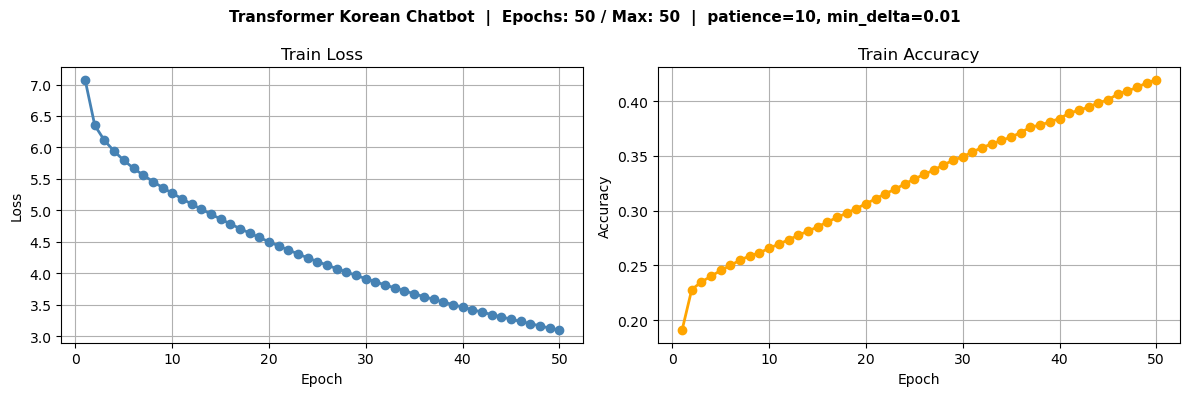


=== Convergence Summary ===
  실제 학습 에폭 : 50 / 최대 50
  초기 Loss  : 7.0743  ->  최종 Loss : 3.0965
  초기 Acc   : 0.1909  ->  최종 Acc  : 0.4195
  Loss 감소율     : 56.2%
  -> Loss decreased & Accuracy increased: Stable convergence!


In [16]:
# 학습 수렴 분석 — Loss / Accuracy 시각화

import matplotlib.pyplot as plt

epochs = range(1, len(epoch_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss 곡선
ax1.plot(epochs, epoch_losses, marker='o', color='steelblue', linewidth=2)
ax1.set_title("Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

# Accuracy 곡선
ax2.plot(epochs, epoch_accs, marker='o', color='orange', linewidth=2)
ax2.set_title("Train Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.suptitle(
    f"Transformer Korean Chatbot  |  "
    f"Epochs: {len(epoch_losses)} / Max: {NUM_EPOCHS}  |  "
    f"patience={PATIENCE}, min_delta={MIN_DELTA}",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# 수렴 분석 요약
print("\n=== Convergence Summary ===")
print(f"  실제 학습 에폭 : {len(epoch_losses)} / 최대 {NUM_EPOCHS}")
print(f"  초기 Loss  : {epoch_losses[0]:.4f}  ->  최종 Loss : {epoch_losses[-1]:.4f}")
print(f"  초기 Acc   : {epoch_accs[0]:.4f}  ->  최종 Acc  : {epoch_accs[-1]:.4f}")
print(f"  Loss 감소율     : {(epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0] * 100:.1f}%")

if epoch_losses[-1] < epoch_losses[0] and epoch_accs[-1] > epoch_accs[0]:
    print("  -> Loss decreased & Accuracy increased: Stable convergence!")
else:
    print("  -> Unstable convergence. Try more epochs or adjust hyperparameters.")

### 12. GPT-1 텍스트 생성 함수
GPT-1은 Decoder-Only 구조이므로 생성 방식이 기존과 다름
- **기존**: 질문(enc_input) → 답변(dec_input) 분리 생성
- **GPT-1**: `[BOS] 질문 [SEP]` 를 프롬프트로 주고 이어서 생성

In [17]:
# GPT-1 텍스트 생성 함수
# GPT-1 (변경):
#   - [BOS] + 질문 + [SEP]를 프롬프트로 구성
#   - model(input_ids) 단일 입력으로 호출
#   - [EOS]가 나올 때까지 다음 토큰 순차 생성

# 함수명 변경: decoder_inference → gpt_generate
def gpt_generate(model, sentence, sp, device="cpu", max_length=40):
    """
    [변경] GPT-1 Auto-Regressive 텍스트 생성

    기존 decoder_inference와의 차이:
    - 제거: enc_input (Encoder 입력) 구성
    - 변경: prompt = [BOS] + 질문 + [SEP] (단일 시퀀스)
    - 변경: model(enc_input, dec_input) → model(input_ids)
    - 유지: EOS 토큰까지 순차 생성 (Auto-Regressive)
    """
    START_TOKEN = sp.bos_id()   # 1
    END_TOKEN   = sp.eos_id()   # 2 (SEP 토큰으로도 사용)

    # 전처리 
    sentence = preprocess_sentence(sentence)

    # GPT-1 프롬프트 구성
    # 기존: enc_ids = [START_TOKEN] + sp.encode(sentence) + [END_TOKEN]
    #        dec_input = [[START_TOKEN]]  (분리)
    # GPT-1: prompt = [BOS] + 질문 + [SEP]  (단일 시퀀스)
    prompt_ids = [START_TOKEN] + sp.encode(sentence) + [END_TOKEN]  # SEP 포함
    input_ids  = torch.tensor([prompt_ids], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        for _ in range(max_length):
            # 단일 입력으로 모델 호출
            # 기존: logits = model(enc_input, dec_input)
            logits = model(input_ids)   # (1, seq_len, vocab_size)

            # 마지막 타임스텝에서 다음 토큰 예측 
            predicted_id = torch.argmax(logits[:, -1, :], dim=-1)

            #  EOS 토큰이면 생성 종료 
            if predicted_id.item() == END_TOKEN:
                break

            # 예측 토큰을 input_ids에 이어붙임
            # 기존: dec_input = torch.cat([dec_input, predicted_id.unsqueeze(0)], dim=1)
            input_ids = torch.cat(
                [input_ids, predicted_id.unsqueeze(0)], dim=1
            )

    # 프롬프트 이후 생성된 부분만 반환
    generated_ids = input_ids.squeeze(0).tolist()[len(prompt_ids):]
    return generated_ids

# 함수명 변경: sentence_generation → gpt_sentence_generation
def gpt_sentence_generation(sentence, model, sp, device="cpu"):
    """
    [변경] GPT-1 기반 답변 생성

    기존 sentence_generation과 차이:
    - 변경: decoder_inference → gpt_generate 호출
    - 유지: 전처리, 디코딩, 출력 방식
    """
    output_ids = gpt_generate(model, sentence, sp, device=device)
    predicted  = sp.decode([tok for tok in output_ids if tok < sp.GetPieceSize()])
    print(f"  입력: {sentence}")
    print(f"  출력: {predicted if predicted else '(생성 없음)'}")
    return predicted

print("GPT-1 생성 함수 정의 완료!")

GPT-1 생성 함수 정의 완료!


### 13. 감정 레이블별 맥락 평가

In [18]:
# sentence_generation → gpt_sentence_generation 사용
# GPT-1 Decoder-Only 구조에 맞는 생성 함수 적용

test_cases = {
    "일상 (label=0)": [
        "오늘 날씨가 너무 좋다",
        "밥 먹었어?",
        "주말에 뭐 할 거야?",
    ],
    "부정 (label=1)": [
        "요즘 너무 힘들어",
        "아무것도 하기 싫다",
        "취업이 너무 어려워",
    ],
    "긍정 (label=2)": [
        "오늘 기분이 너무 좋아",
        "드디어 취업했어",
        "사랑하는 사람이 생겼어",
    ],
}

print("=== GPT-1 감정 레이블별 맥락 평가 ===\n")
for label, sentences in test_cases.items():
    print(f"[ {label} ]")
    for sent in sentences:
        # sentence_generation → gpt_sentence_generation
        gpt_sentence_generation(sent, model, sp, device=device)
    print()

=== GPT-1 감정 레이블별 맥락 평가 ===

[ 일상 (label=0) ]
  입력: 오늘 날씨가 너무 좋다
  출력: 저도 좀 더 많이 만나보세요 .
  입력: 밥 먹었어?
  출력: 저는 마음을 이어주는 위로봇입니다 .
  입력: 주말에 뭐 할 거야?
  출력: 안 좋은 사람 만날 수 있을 거예요 .

[ 부정 (label=1) ]
  입력: 요즘 너무 힘들어
  출력: 더 좋은 사람 만날 수 있을 거예요 .
  입력: 아무것도 하기 싫다
  출력: 잘 살 수 있을 거예요 .
  입력: 취업이 너무 어려워
  출력: 좋은 사람 만날 수 있을 거예요 .

[ 긍정 (label=2) ]
  입력: 오늘 기분이 너무 좋아
  출력: 저도 데려가세요 .
  입력: 드디어 취업했어
  출력: 좋은 사람 만날 수 있을 거예요 .
  입력: 사랑하는 사람이 생겼어
  출력: 그 사람을 잊는다는 건 쉬운 일이 아니니까요 .



### 14. 테스트

In [19]:
# GPT-1 기반 대화형 테스트
# sentence_generation → gpt_sentence_generation 사용

print("=== GPT-1 한국어 언어 모델 ===")
print("종료하려면 'quit' 또는 'exit' 를 입력하세요.\n")

while True:
    user_input = input("나: ").strip()

    if not user_input:
        continue

    if user_input.lower() in ("quit", "exit"):
        print("종료합니다.")
        break

    # [변경] sentence_generation → gpt_sentence_generation
    gpt_sentence_generation(user_input, model, sp, device=device)
    print()

=== GPT-1 한국어 언어 모델 ===
종료하려면 'quit' 또는 'exit' 를 입력하세요.



나:  요즘 너무 외로워


  입력: 요즘 너무 외로워
  출력: 더 좋은 사람 만날 수 있을 거예요 .



나:  오늘 정말 행복해


  입력: 오늘 정말 행복해
  출력: 오늘 일찍 주무세요 .



...

  입력: 드디어 시험에 합격했어
  출력: 좋은 사람 만날 수 있을 거예요 .



나:  좋아하는 사람이 생겼어


  입력: 좋아하는 사람이 생겼어
  출력: 먼저 다가왔네요 .



나:  exit


종료합니다.


### 15. 실제 데이터셋 기반 테스트

In [20]:
# 실제 데이터셋 기반 테스트
# ChatbotData.csv에서 실제 질문을 뽑아서 테스트
# 모델이 학습한 데이터와 비슷한 질문 / 처음 보는 질문 두 가지로 나눠서
# 성능 차이를 확인

import random

# 학습 데이터에서 실제 질문 10개 무작위 추출
random.seed(42)
sample_pairs = random.sample(cleaned_pairs, 10)

print("=== 실제 데이터셋 기반 GPT-1 성능 테스트 ===\n")
print("[ 학습 데이터에서 뽑은 실제 질문 테스트 ]")
print("기대: 학습한 질문과 비슷하므로 비교적 자연스러운 답변이 나와야 합니다.\n")

for i, (q, real_a) in enumerate(sample_pairs):
    print(f"[테스트 {i+1}]")
    print(f"  실제 답변 : {real_a}")
    gpt_sentence_generation(q, model, sp, device=device)
    print()

# 레이블별 실제 질문 추출 
print("\n[ 감정 레이블별 실제 질문 테스트 ]\n")

label_groups = {0: [], 1: [], 2: []}
for _, row in df.iterrows():
    label_groups[row['label']].append((row['Q'], row['A']))

label_names = {0: "일상", 1: "부정/고민", 2: "긍정"}

for label, name in label_names.items():
    samples = random.sample(label_groups[label], 3)
    print(f"[ {name} (label={label}) ]")
    for q, real_a in samples:
        q_clean = preprocess_sentence(q)
        print(f"  실제 답변 : {real_a}")
        gpt_sentence_generation(q_clean, model, sp, device=device)
    print()

=== 실제 데이터셋 기반 GPT-1 성능 테스트 ===

[ 학습 데이터에서 뽑은 실제 질문 테스트 ]
기대: 학습한 질문과 비슷하므로 비교적 자연스러운 답변이 나와야 합니다.

[테스트 1]
  실제 답변 : 너랑 약속잡으려고 한다고 말해보세요 .
  입력: 어떤 남자애가 나 내일 뭐하냐는데 뭐라하지 ?
  출력: 시간 가는 게 좋을 것 같아요 .

[테스트 2]
  실제 답변 : 계속 그러면 말하세요 .
  입력: 뭐라 하려다 참았어
  출력: 좋은 곳으로 관심을 가져가세요 .

[테스트 3]
  실제 답변 : 조심하세요 .
  입력: 길이 미끄러워서 미끄러질뻔했어
  출력: 조심하세요 .

[테스트 4]
  실제 답변 : 회사에서 꼼수를 쓰는 건 아닌지 확인해보세요 .
  입력: 최저임금 올랐다는데 월급은 왜 똑같지 ?
  출력: 아무래도 그렇겠죠 .

[테스트 5]
  실제 답변 : 재미있는 다른걸 찾아보세요 .
  입력: 재미있는 드라마 끝났어
  출력: 저도 좀 더 많이 하면 돼요 .

[테스트 6]
  실제 답변 : 어서 치과에 가보세요 .
  입력: 이 썩은 거 같아
  출력: 포맷해보세요 .

[테스트 7]
  실제 답변 : 처음 배우는게 중요해요 .
  입력: 사수가 깐깐하게 군다
  출력: 다른 곳에 쓰려고 운을 아껴뒀나봐요 .

[테스트 8]
  실제 답변 : 회사와 자신에 대해서 더 공부해서 자신감을 가져보세요 .
  입력: 면접 준비중이야
  출력: 회사와 자신에 대해서 더 공부해서 자신감을 가져보세요 .

[테스트 9]
  실제 답변 : 생각만해도 소름돋네요 .
  입력: 좋아하는 사람 앞에서 실례를 했어 .
  출력: 마음을 정리하는게 좋겠어요 .

[테스트 10]
  실제 답변 : 만나서 같이 있음 헤어지기 싫었나봅니다 .
  입력: 결혼 결심 이유
  출력: 좋은 사람 만날 수 있을 거예요 .


[ 감정 레이블별 실제 질문 테스트 ]

[ 일상 (label=0) ]
  실제 답변 : 소개팅 시켜달라고 말해보세요.
  입력: 

#### 리뷰
1. 19개 질문 모두 한국어로 출력 생성 -> 모델 정상 동작 확인
2. "길이 미끄러워서 미끄러질뻔했어", "면접 준비중이야" 두 개는 실제 데이터셋 답변과 완전히 동일하게 출력
3. 전체 32% 만 맥락에 맞는 답변
4. "좋은 사람 만날 수 있을 거예요" 패턴이 여러 질문에서 반복
5. "이 썩은 거 같아 -> 포맷해보세요" 처럼 엉뚱한 답변도 있음
   - 학습 데이터 11,000개는 GPT-1에 비해 너무 적은량이 아닌가 생각이 듬
   - 실제 GPT-1 논문에서는 7,000권 이상의 책으로 사전학습